<div style="margin-bottom: 32px;">
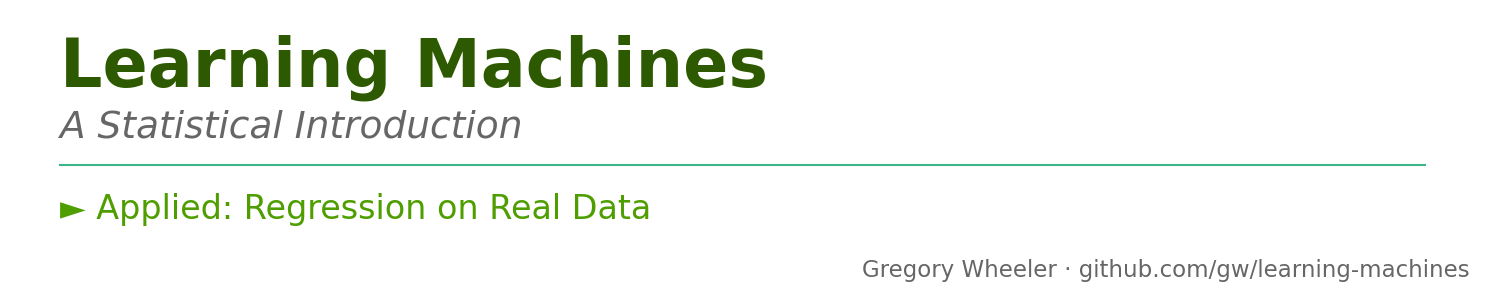
</div>


# Applied: Regression on Real Data

The chapter develops ordinary least squares, the normal equations, and polynomial regression on the Frankfurt housing example. This notebook carries those same tools to two real datasets---California house prices and automobile fuel economy---so the ideas are not tied to a single table of numbers.

**What computation adds**: on real data the chapter's warnings become concrete. We watch collinear features make individual coefficients unstable, see standardization change what a coefficient *means*, and watch a polynomial begin to chase noise as its degree grows.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Colab: fetch the plot-style helper if it isn't beside this notebook
import os as _os, urllib.request as _ur
if not _os.path.exists("mlone_theme.py"):
    _BASE = "https://raw.githubusercontent.com/welr/learning_machines/main/"
    for _f in ("mlone_theme.py", "mlone_style.mplstyle"):
        _ur.urlretrieve(_BASE + _f, _f)
import mlone_theme as mt

plt.style.use("mlone_style.mplstyle")
mt.set_notebook_mode()                 # green companion-notebook palette
np.set_printoptions(precision=4, suppress=True)

## California housing

The California housing dataset records the median house value in each of 20,640 census block groups, with eight features such as median income, average rooms per household, and location. We fit a multiple linear regression by the normal equations of Chapter 2, solving $\mathbf{X}^\top\mathbf{X}\,\hat{\boldsymbol{\theta}} = \mathbf{X}^\top\mathbf{y}$ directly.

In [2]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
X_raw, y = data.data, data.target
feature_names = list(data.feature_names)
print(f"{X_raw.shape[0]} block groups, {X_raw.shape[1]} features:")
print(feature_names)

def ols_normal_equations(X, y):
    """Solve the normal equations directly; column 0 is the intercept."""
    X_design = np.column_stack([np.ones(len(X)), X])
    return np.linalg.solve(X_design.T @ X_design, X_design.T @ y)

theta = ols_normal_equations(X_raw, y)
for name, b in zip(["intercept"] + feature_names, theta):
    print(f"{name:>11}: {b:9.4f}")

20640 block groups, 8 features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
  intercept:  -36.9419
     MedInc:    0.4367
   HouseAge:    0.0094
   AveRooms:   -0.1073
  AveBedrms:    0.6451
 Population:   -0.0000
   AveOccup:   -0.0038
   Latitude:   -0.4213
  Longitude:   -0.4345


### Collinear features

`AveRooms` and `AveBedrms` measure almost the same thing, so their columns are strongly correlated. The chapter warned that when columns of $\mathbf{X}$ are nearly linearly dependent, $\mathbf{X}^\top\mathbf{X}$ is ill-conditioned and the individual coefficients are hard to pin down, even when the model as a whole predicts well. Dropping one of the pair moves the other's coefficient sharply.

In [3]:
i = feature_names.index("AveRooms")
j = feature_names.index("AveBedrms")
print(f"corr(AveRooms, AveBedrms) = {np.corrcoef(X_raw[:, i], X_raw[:, j])[0, 1]:.3f}")
print(f"AveRooms  coefficient (full model):        {theta[1 + i]:9.4f}")
print(f"AveBedrms coefficient (full model):        {theta[1 + j]:9.4f}")

keep = [k for k in range(X_raw.shape[1]) if k != j]
theta_drop = ols_normal_equations(X_raw[:, keep], y)
print(f"AveRooms  coefficient (AveBedrms dropped):  {theta_drop[1 + keep.index(i)]:9.4f}")

corr(AveRooms, AveBedrms) = 0.848
AveRooms  coefficient (full model):          -0.1073
AveBedrms coefficient (full model):           0.6451
AveRooms  coefficient (AveBedrms dropped):     0.0170


### Standardization, and what a coefficient means

The raw coefficients are not comparable: income is in tens of thousands, latitude in degrees, so a coefficient's size reflects its units as much as its influence. Standardizing each feature to zero mean and unit variance puts them on a common scale, after which the features that move the prediction most are the ones the domain would predict: location (latitude and longitude) and median income, in a near three-way tie.

In [4]:
X_std = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
theta_std = ols_normal_equations(X_std, y)

order = np.argsort(np.abs(theta_std[1:]))[::-1]
print("standardized coefficients, largest magnitude first:")
for k in order:
    print(f"{feature_names[k]:>11}: {theta_std[1 + k]:9.4f}")

standardized coefficients, largest magnitude first:
   Latitude:   -0.8999
  Longitude:   -0.8705
     MedInc:    0.8296
  AveBedrms:    0.3057
   AveRooms:   -0.2655
   HouseAge:    0.1188
   AveOccup:   -0.0393
 Population:   -0.0045


The lesson the chapter draws on the Frankfurt data holds here: a *raw* coefficient is not a measure of importance, and two collinear features split the credit for an effect between them in a way no single number reports reliably.

## Automobile fuel economy

A different domain. The auto-mpg dataset records the fuel economy of 398 cars from the 1970s and 80s, with features such as weight, horsepower, and model year. We model mpg from a single feature, weight, and watch what happens as we let the curve bend.

In [5]:
from sklearn.datasets import fetch_openml

cars = fetch_openml(data_id=196, as_frame=True)        # UCI auto-mpg
frame = cars.frame.dropna(subset=["weight"])
weight = frame["weight"].astype(float).to_numpy()
mpg = cars.target.loc[frame.index].astype(float).to_numpy()
print(f"{len(weight)} cars; mpg {mpg.min():.0f}-{mpg.max():.0f}, weight {weight.min():.0f}-{weight.max():.0f} lbs")

398 cars; mpg 9-47, weight 1613-5140 lbs


Heavier cars use more fuel, so we expect a downward trend. A straight line captures it; a quadratic captures the gentle flattening at the heavy end; a high-degree polynomial captures those *and* the noise. We fit on a standardized weight so the high powers stay numerically well behaved, then plot every fit on the original scale.

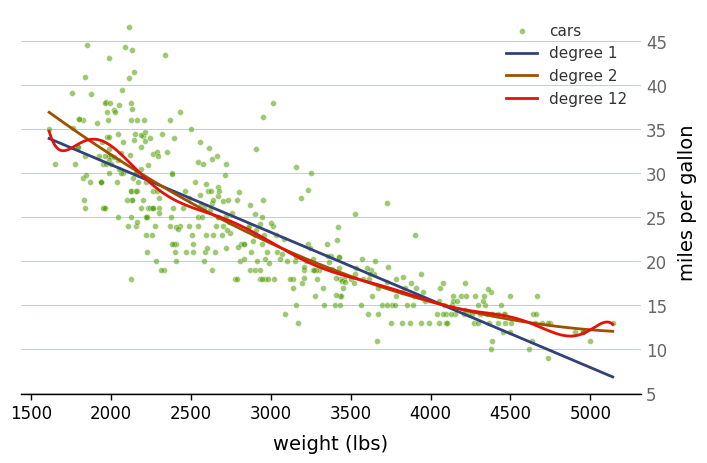

In [6]:
w_std = (weight - weight.mean()) / weight.std()
grid_w = np.linspace(weight.min(), weight.max(), 300)
grid_std = (grid_w - weight.mean()) / weight.std()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(weight, mpg, s=18, color=mt.GREEN, alpha=0.55,
           edgecolors="white", linewidths=0.4, label="cars")
for degree, color in [(1, mt.FS_BLUE), (2, mt.ORANGE), (12, mt.RED)]:
    coeffs = np.polyfit(w_std, mpg, degree)            # least squares, computed stably
    ax.plot(grid_w, np.polyval(coeffs, grid_std), color=color, lw=2, label=f"degree {degree}")
ax.set_xlabel("weight (lbs)")
ax.set_ylabel("miles per gallon")
ax.legend()
mt.apply_book_style(ax)
plt.show()

The line and the quadratic tell the same honest story. The degree-12 polynomial fits the training cars a little better, but buys it by wriggling, diving and rising at the sparse heavy end where a few cars pull it around. On *new* cars that wriggle would cost it: it has fit the noise, not the trend. We have no formal measure of that cost yet; Chapter 6 supplies one, and Chapter 7 the tools to prevent it.

**Try next.** Refit mpg on `horsepower` instead of weight (minding the missing values), or on weight *and* model year together, and ask whether the extra feature earns its place.